In [1]:
# 安装任务需要的库
!pip install PyGithub boto3 -q


# =========================
# 1. 导入 Python 库
# =========================

import os
import random
import boto3
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from datetime import datetime
from getpass import getpass
from github import Github, Auth
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.preprocessing import image


# =========================
# 2. 固定随机种子
# =========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


# =========================
# 3. 检查 TensorFlow 和 GPU
# =========================

print("TensorFlow version:", tf.__version__)

gpu_devices = tf.config.list_physical_devices("GPU")

if gpu_devices:
    print("GPU is available:", gpu_devices)
else:
    print("GPU is not available.")
    print("Please select: Runtime > Change runtime type > T4 GPU")


# =========================
# 4. 文件和目录配置
# =========================

MODEL_FILENAME = "cifar_custom_cnn.h5"
README_FILENAME = "README.md"
NOTEBOOK_FILENAME = "CIFAR10_CNN_Week5_6.ipynb"

# GitHub 配置
REPO_NAME = "ZhangHui88888/mds7-Hui-Zhang"
TARGET_FOLDER = "week-05-06-bigquery/cifar_cnn"

# AWS S3 配置
REGION_NAME = "eu-north-1"
BUCKET_NAME = "mds7-hui-zhang-titanic"
S3_PREFIX = "deeplearning"


# =========================
# 5. 安全输入凭证
# =========================

# 输入时不会显示，也不会写入 Notebook
AWS_ACCESS_KEY_ID = getpass("Enter AWS Access Key ID: ")
AWS_SECRET_ACCESS_KEY = getpass("Enter AWS Secret Access Key: ")
GITHUB_TOKEN = getpass("Enter GitHub Personal Access Token: ")


# =========================
# 6. 创建 S3 和 GitHub 客户端
# =========================

s3_client = boto3.client(
    "s3",
    aws_access_key_id=AWS_ACCESS_KEY_ID,
    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
    region_name=REGION_NAME
)

github_auth = Auth.Token(GITHUB_TOKEN)
github_client = Github(auth=github_auth)
repo = github_client.get_repo(REPO_NAME)

# 自动读取仓库默认分支
TARGET_BRANCH = repo.default_branch


# =========================
# 7. 输出配置结果
# =========================

print("\nEnvironment setup complete.")
print("GitHub repository:", REPO_NAME)
print("GitHub branch:", TARGET_BRANCH)
print("GitHub folder:", TARGET_FOLDER)
print("S3 bucket:", BUCKET_NAME)
print("S3 prefix:", S3_PREFIX)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.7/449.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.5/15.5 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 3.3 MB/s eta 0:00:00
TensorFlow version: 2.20.0
GPU is not available.
Please select: Runtime > Change runtime type > T4 GPU

Environment setup complete.
GitHub repository: ZhangHui88888/mds7-Hui-Zhang
GitHub branch: main
GitHub folder: week-05-06-bigquery/cifar_cnn
S3 bucket: mds7-hui-zhang-titanic
S3 prefix: deeplearning


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2118s 12us/step

Dataset downloaded successfully.
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test images shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)

Pixel value range:
Minimum: 0
Maximum: 255


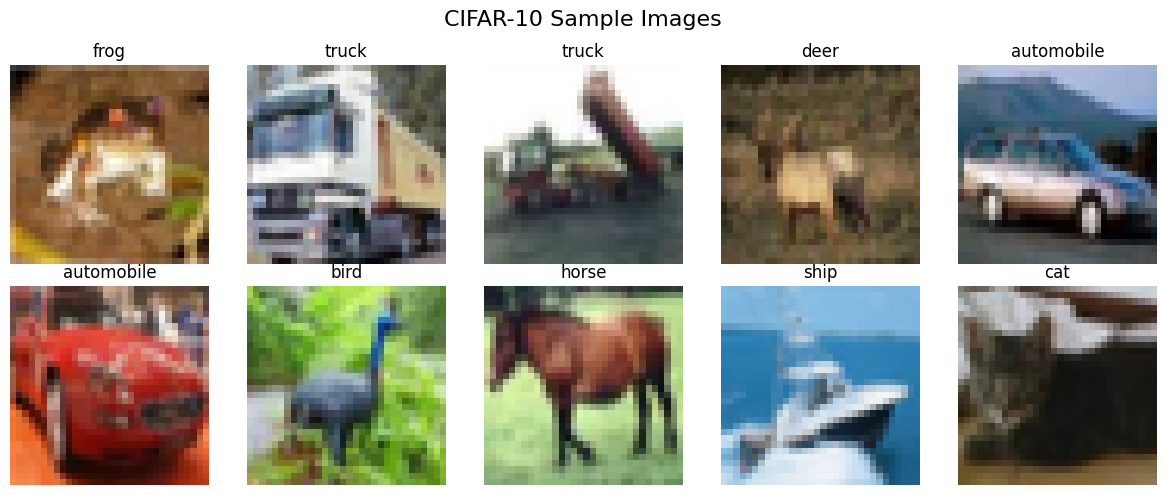

In [2]:
# =========================
# 2. 下载并检查 CIFAR-10 数据
# =========================

print("Downloading CIFAR-10 dataset...")

# TensorFlow 自动下载并划分训练集和测试集
(train_images, train_labels), (test_images, test_labels) = (
    datasets.cifar10.load_data()
)


# CIFAR-10 的十个类别
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]


# 查看数据形状
print("\nDataset downloaded successfully.")
print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

print("\nPixel value range:")
print("Minimum:", train_images.min())
print("Maximum:", train_images.max())


# 显示前 10 张训练图片
plt.figure(figsize=(12, 5))

for index in range(10):
    plt.subplot(2, 5, index + 1)
    plt.imshow(train_images[index])
    plt.title(class_names[int(train_labels[index, 0])])
    plt.axis("off")

plt.suptitle("CIFAR-10 Sample Images", fontsize=16)
plt.tight_layout()
plt.show()

In [3]:
# =========================
# 3. 数据预处理：像素归一化
# =========================

# 转换为 float32，减少内存使用
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0


# 将标签从二维转换为一维
train_labels = train_labels.squeeze()
test_labels = test_labels.squeeze()


# 检查处理结果
print("Data preprocessing complete.")

print("\nTraining images shape:", train_images.shape)
print("Test images shape:", test_images.shape)

print("\nTraining labels shape:", train_labels.shape)
print("Test labels shape:", test_labels.shape)

print("\nNormalized pixel range:")
print("Minimum:", train_images.min())
print("Maximum:", train_images.max())

print("\nFirst 10 labels:")
print(train_labels[:10])

Data preprocessing complete.

Training images shape: (50000, 32, 32, 3)
Test images shape: (10000, 32, 32, 3)

Training labels shape: (50000,)
Test labels shape: (10000,)

Normalized pixel range:
Minimum: 0.0
Maximum: 1.0

First 10 labels:
[6 9 9 4 1 1 2 7 8 3]


In [4]:
# =========================
# 4. 建立自定义 CNN 模型
# =========================

custom_model = models.Sequential([
    # 输入：32 × 32 彩色图片
    layers.Input(shape=(32, 32, 3)),

    # 第一个卷积与池化模块
    layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # 第二个卷积与池化模块
    layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D(pool_size=(2, 2)),

    # 将二维特征转换为一维
    layers.Flatten(),

    # 全连接层
    layers.Dense(
        units=64,
        activation="relu"
    ),

    # CIFAR-10 有十个类别
    # 此处不使用 softmax，训练时设置 from_logits=True
    layers.Dense(units=10)
])


# 显示模型结构
custom_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# =========================
# 5. 编译并训练自定义 CNN
# =========================

# 编译模型
custom_model.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True
    ),
    metrics=["accuracy"]
)


# 防止训练时间过长和过拟合
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=8,
    mode="max",
    restore_best_weights=True,
    verbose=1
)


print("Training custom CIFAR-10 CNN...")


# 最多训练 100 轮
# 如果验证准确率连续 8 轮没有提升，会自动停止
history = custom_model.fit(
    train_images,
    train_labels,
    epochs=100,
    batch_size=64,
    validation_data=(test_images, test_labels),
    callbacks=[early_stopping],
    verbose=1
)

Training custom CIFAR-10 CNN...
Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 63s 78ms/step - accuracy: 0.4703 - loss: 1.4779 - val_accuracy: 0.5669 - val_loss: 1.2194
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 82s 78ms/step - accuracy: 0.6010 - loss: 1.1402 - val_accuracy: 0.6218 - val_loss: 1.0755
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 76ms/step - accuracy: 0.6463 - loss: 1.0201 - val_accuracy: 0.6494 - val_loss: 1.0061
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 79ms/step - accuracy: 0.6750 - loss: 0.9395 - val_accuracy: 0.6665 - val_loss: 0.9725
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 80ms/step - accuracy: 0.6976 - loss: 0.8746 - val_accuracy: 0.6753 - val_loss: 0.9509
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 78ms/step - accuracy: 0.7191 - loss: 0.8160 - val_accuracy: 0.6853 - val_loss: 0.9321
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 77ms/step - accuracy: 0.7384 - loss: 0.7629 - val_accuracy: 0.6979 - val_loss: 0.9085
Epoch 8/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 76ms/s

Test Loss: 0.9085
Test Accuracy: 0.6979
Test Accuracy Percentage: 69.79%


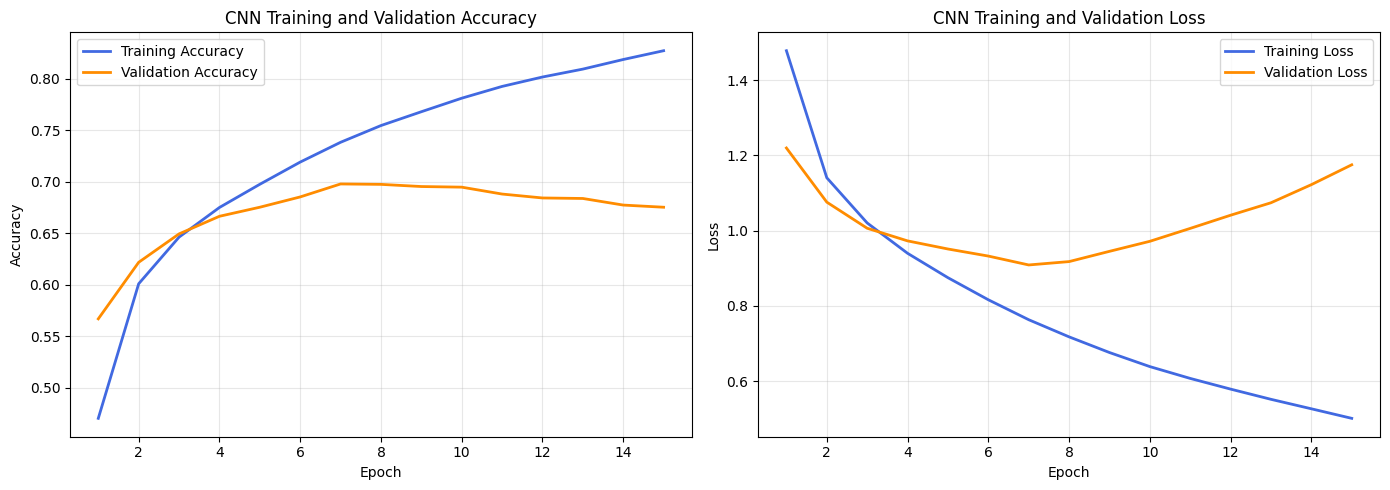

In [6]:
# =========================
# 6. 评估模型并绘制训练曲线
# =========================

# 在测试集上进行最终评估
test_loss, test_accuracy = custom_model.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Accuracy Percentage: {test_accuracy * 100:.2f}%")


# 获取每一轮的训练记录
training_accuracy = history.history["accuracy"]
validation_accuracy = history.history["val_accuracy"]
training_loss = history.history["loss"]
validation_loss = history.history["val_loss"]

epoch_numbers = range(1, len(training_accuracy) + 1)


# 创建训练曲线
plt.figure(figsize=(14, 5))


# -------------------------
# Accuracy 曲线
# -------------------------
plt.subplot(1, 2, 1)

plt.plot(
    epoch_numbers,
    training_accuracy,
    label="Training Accuracy",
    color="royalblue",
    linewidth=2
)

plt.plot(
    epoch_numbers,
    validation_accuracy,
    label="Validation Accuracy",
    color="darkorange",
    linewidth=2
)

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)


# -------------------------
# Loss 曲线
# -------------------------
plt.subplot(1, 2, 2)

plt.plot(
    epoch_numbers,
    training_loss,
    label="Training Loss",
    color="royalblue",
    linewidth=2
)

plt.plot(
    epoch_numbers,
    validation_loss,
    label="Validation Loss",
    color="darkorange",
    linewidth=2
)

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)


plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

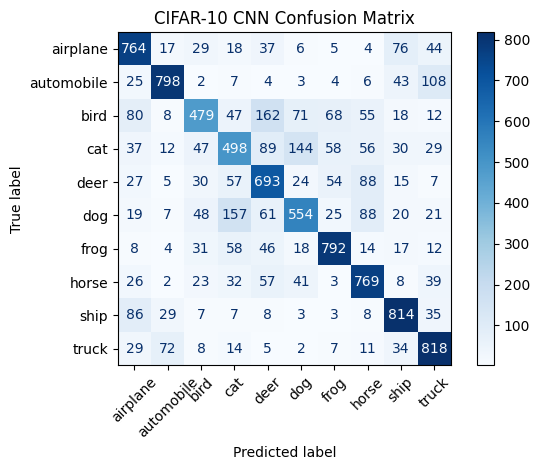

Classification Report:

              precision    recall  f1-score   support

    airplane     0.6939    0.7640    0.7273      1000
  automobile     0.8365    0.7980    0.8168      1000
        bird     0.6804    0.4790    0.5622      1000
         cat     0.5564    0.4980    0.5256      1000
        deer     0.5964    0.6930    0.6411      1000
         dog     0.6397    0.5540    0.5938      1000
        frog     0.7772    0.7920    0.7845      1000
       horse     0.6997    0.7690    0.7327      1000
        ship     0.7572    0.8140    0.7846      1000
       truck     0.7271    0.8180    0.7699      1000

    accuracy                         0.6979     10000
   macro avg     0.6965    0.6979    0.6938     10000
weighted avg     0.6965    0.6979    0.6938     10000



In [7]:
# =========================
# 7. 生成预测结果和混淆矩阵
# =========================

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)


# 模型输出的是 logits
prediction_logits = custom_model.predict(
    test_images,
    verbose=0
)

# 取分数最高的类别
predicted_labels = np.argmax(
    prediction_logits,
    axis=1
)


# 计算混淆矩阵
cnn_confusion_matrix = confusion_matrix(
    test_labels,
    predicted_labels
)


# 绘制混淆矩阵
plt.figure(figsize=(10, 8))

display = ConfusionMatrixDisplay(
    confusion_matrix=cnn_confusion_matrix,
    display_labels=class_names
)

display.plot(
    cmap="Blues",
    xticks_rotation=45,
    values_format="d"
)

plt.title("CIFAR-10 CNN Confusion Matrix")
plt.tight_layout()
plt.show()


# 输出各类别的 Precision、Recall 和 F1 Score
print("Classification Report:\n")

print(
    classification_report(
        test_labels,
        predicted_labels,
        target_names=class_names,
        digits=4
    )
)

In [8]:
# =========================
# 8. 保存并验证最佳 CNN 模型
# =========================

# 保存 Early Stopping 恢复后的最佳模型
custom_model.save(MODEL_FILENAME)

print(f"Model saved successfully: {MODEL_FILENAME}")


# 显示模型文件大小
model_size_mb = os.path.getsize(MODEL_FILENAME) / (1024 * 1024)

print(f"Model file size: {model_size_mb:.2f} MB")


# -------------------------
# 重新加载模型
# -------------------------

loaded_model = tf.keras.models.load_model(
    MODEL_FILENAME
)


# 重新评估，验证模型文件是否正常
loaded_test_loss, loaded_test_accuracy = loaded_model.evaluate(
    test_images,
    test_labels,
    verbose=0
)

print("\nReloaded model verification:")
print(f"Test Loss: {loaded_test_loss:.4f}")
print(f"Test Accuracy: {loaded_test_accuracy:.4f}")
print(
    f"Test Accuracy Percentage: "
    f"{loaded_test_accuracy * 100:.2f}%"
)

Model saved successfully: cifar_custom_cnn.h5
Model file size: 1.95 MB

Reloaded model verification:
Test Loss: 0.9085
Test Accuracy: 0.6979
Test Accuracy Percentage: 69.79%


Please upload an image of an airplane, automobile, bird, cat, deer, dog, frog, horse, ship, or truck.


Saving images.webp to images.webp


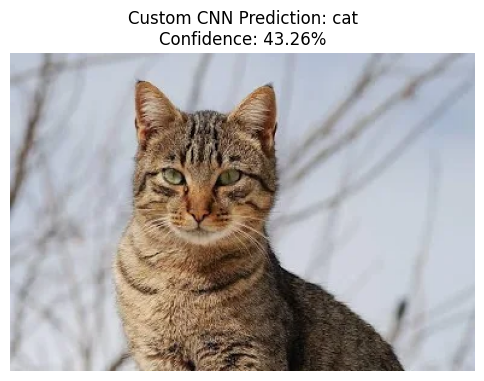

Top 3 predictions:
1. cat: 43.26%
2. dog: 19.76%
3. frog: 15.45%


In [9]:
# =========================
# 9. 上传图片并测试自定义 CNN
# =========================

from google.colab import files

print(
    "Please upload an image of an airplane, automobile, bird, "
    "cat, deer, dog, frog, horse, ship, or truck."
)

uploaded_images = files.upload()


for uploaded_filename in uploaded_images.keys():

    # -------------------------
    # 读取原始图片
    # -------------------------
    original_image = image.load_img(
        uploaded_filename
    )

    # 将图片调整为 CIFAR-10 使用的 32 × 32
    resized_image = image.load_img(
        uploaded_filename,
        target_size=(32, 32)
    )

    # 转换成 NumPy 数组
    image_array = image.img_to_array(
        resized_image
    )

    # 归一化到 0–1
    image_array = image_array.astype(
        "float32"
    ) / 255.0

    # 增加 batch 维度
    image_batch = tf.expand_dims(
        image_array,
        axis=0
    )


    # -------------------------
    # 使用自定义 CNN 预测
    # -------------------------
    prediction_logits = loaded_model.predict(
        image_batch,
        verbose=0
    )

    prediction_probabilities = tf.nn.softmax(
        prediction_logits[0]
    ).numpy()

    predicted_index = int(
        np.argmax(prediction_probabilities)
    )

    predicted_class = class_names[
        predicted_index
    ]

    confidence = (
        prediction_probabilities[predicted_index]
        * 100
    )


    # 获取概率最高的三个类别
    top_three_indices = np.argsort(
        prediction_probabilities
    )[-3:][::-1]


    # -------------------------
    # 显示结果
    # -------------------------
    plt.figure(figsize=(6, 5))
    plt.imshow(original_image)
    plt.axis("off")
    plt.title(
        f"Custom CNN Prediction: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )
    plt.show()


    print("Top 3 predictions:")

    for rank, class_index in enumerate(
        top_three_indices,
        start=1
    ):
        print(
            f"{rank}. "
            f"{class_names[class_index]}: "
            f"{prediction_probabilities[class_index] * 100:.2f}%"
        )

Loading pre-trained MobileNetV2...
14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully.
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


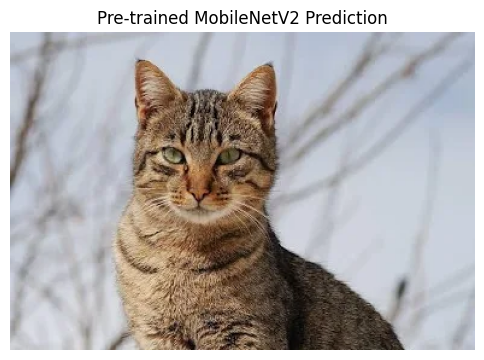

MobileNetV2 Top 5 predictions:
1. tiger_cat: 52.62%
2. tabby: 19.86%
3. Egyptian_cat: 11.82%
4. lynx: 2.39%
5. wood_rabbit: 0.33%


In [10]:
# =========================
# 10. 使用预训练 MobileNetV2 预测同一图片
# =========================

print("Loading pre-trained MobileNetV2...")

# 下载使用 ImageNet 训练过的 MobileNetV2
pretrained_model = (
    tf.keras.applications.MobileNetV2(
        weights="imagenet"
    )
)

print("MobileNetV2 loaded successfully.")


for uploaded_filename in uploaded_images.keys():

    # MobileNetV2 需要 224 × 224 的图片
    mobilenet_image = image.load_img(
        uploaded_filename,
        target_size=(224, 224)
    )

    mobilenet_array = image.img_to_array(
        mobilenet_image
    )

    mobilenet_batch = tf.expand_dims(
        mobilenet_array,
        axis=0
    )

    # 使用 MobileNetV2 专用预处理
    mobilenet_batch = (
        tf.keras.applications.mobilenet_v2
        .preprocess_input(mobilenet_batch)
    )


    # 进行预测
    mobilenet_predictions = (
        pretrained_model.predict(
            mobilenet_batch,
            verbose=0
        )
    )


    # 获取概率最高的五个结果
    decoded_predictions = (
        tf.keras.applications.mobilenet_v2
        .decode_predictions(
            mobilenet_predictions,
            top=5
        )[0]
    )


    # 显示图片
    plt.figure(figsize=(6, 5))
    plt.imshow(
        image.load_img(uploaded_filename)
    )
    plt.axis("off")
    plt.title(
        "Pre-trained MobileNetV2 Prediction"
    )
    plt.show()


    print("MobileNetV2 Top 5 predictions:")

    for rank, (
        imagenet_id,
        predicted_label,
        probability
    ) in enumerate(
        decoded_predictions,
        start=1
    ):
        print(
            f"{rank}. "
            f"{predicted_label}: "
            f"{probability * 100:.2f}%"
        )

In [11]:
# =========================
# 11. 生成项目 README.md
# =========================

from sklearn.metrics import f1_score


# 计算 Macro F1 Score
macro_f1 = f1_score(
    test_labels,
    predicted_labels,
    average="macro"
)


# 获取 MobileNetV2 第一名预测
mobilenet_top_label = decoded_predictions[0][1]
mobilenet_top_confidence = (
    decoded_predictions[0][2] * 100
)


readme_content = f"""# CIFAR-10 Convolutional Neural Network

## Project Overview

This project implements a custom Convolutional Neural Network
for classifying images from the CIFAR-10 dataset.

The CIFAR-10 dataset contains 60,000 color images across
10 different categories.

## CIFAR-10 Classes

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

## Custom CNN Architecture

1. Conv2D layer with 32 filters
2. MaxPooling2D layer
3. Conv2D layer with 64 filters
4. MaxPooling2D layer
5. Flatten layer
6. Dense layer with 64 neurons
7. Output layer with 10 neurons

## Training Configuration

- Optimizer: Adam
- Loss function: Sparse Categorical Crossentropy
- Maximum epochs: 100
- Early stopping patience: 8
- Input image size: 32 x 32 x 3

## Model Performance

- Test Accuracy: {test_accuracy * 100:.2f}%
- Test Loss: {test_loss:.4f}
- Macro F1 Score: {macro_f1:.4f}
- Model file size: {model_size_mb:.2f} MB

## Real Image Prediction

### Custom CIFAR-10 CNN

- Predicted class: {predicted_class}
- Confidence: {confidence:.2f}%

### Pre-trained MobileNetV2

- Predicted class: {mobilenet_top_label}
- Confidence: {mobilenet_top_confidence:.2f}%

## Model Artifact

The trained custom model is saved as:

`cifar_custom_cnn.h5`

## Deployment

The project artifacts are prepared for deployment to:

- GitHub: `{TARGET_FOLDER}/`
- AWS S3: `s3://{BUCKET_NAME}/{S3_PREFIX}/`
"""


# 保存 README
with open(
    README_FILENAME,
    "w",
    encoding="utf-8"
) as readme_file:
    readme_file.write(readme_content)


print(f"README created successfully: {README_FILENAME}")
print("\n" + readme_content)

README created successfully: README.md

# CIFAR-10 Convolutional Neural Network

## Project Overview

This project implements a custom Convolutional Neural Network
for classifying images from the CIFAR-10 dataset.

The CIFAR-10 dataset contains 60,000 color images across
10 different categories.

## CIFAR-10 Classes

- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

## Custom CNN Architecture

1. Conv2D layer with 32 filters
2. MaxPooling2D layer
3. Conv2D layer with 64 filters
4. MaxPooling2D layer
5. Flatten layer
6. Dense layer with 64 neurons
7. Output layer with 10 neurons

## Training Configuration

- Optimizer: Adam
- Loss function: Sparse Categorical Crossentropy
- Maximum epochs: 100
- Early stopping patience: 8
- Input image size: 32 x 32 x 3

## Model Performance

- Test Accuracy: 69.79%
- Test Loss: 0.9085
- Macro F1 Score: 0.6938
- Model file size: 1.95 MB

## Real Image Prediction

### Custom CIFAR-10 CNN

- Predicted class: cat
- Confidence